In [2]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
from tqdm import tqdm
import time
import os
from scipy.signal import medfilt, savgol_filter

In [38]:
# ---- Setup ----
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils

hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ---- Input video ----
input_path = "Study1_Videos/2024-01-15_14-03-23.mp4"
cap = cv2.VideoCapture(input_path)

if not cap.isOpened():
    raise IOError(f"❌ Cannot open video file: {input_path}")

# ---- Prepare output video writer ----
# Extract video info
fps = int(cap.get(cv2.CAP_PROP_FPS))
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Define output path and codec
output_dir = "output_videos"
os.makedirs(output_dir, exist_ok=True)
output_path = os.path.join(output_dir, "tracked_" + os.path.basename(input_path))

fourcc = cv2.VideoWriter_fourcc(*'mp4v')  # Codec for .mp4
out = cv2.VideoWriter(output_path, fourcc, fps, (width, height))

print(f"🎥 Saving output to: {output_path}")
print(f"Video resolution: {width}x{height}, FPS: {fps}")

🎥 Saving output to: output_videos/tracked_2024-01-15_14-03-23.mp4
Video resolution: 1920x1080, FPS: 30


I0000 00:00:1762181183.032709 7123409 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine


W0000 00:00:1762181183.088621 7259633 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762181183.109635 7259633 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


In [79]:
import cv2
import mediapipe as mp
import numpy as np
import os
import time

# ---- Setup ----
mp_hands = mp.solutions.hands
mp_drawing = mp.solutions.drawing_utils
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ---- Input video ----
input_path = "Study1_Videos/2024-01-15_13-18-23.mp4"
cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video file: {input_path}")

fps_video = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# ---- Output ----
os.makedirs("output_videos", exist_ok=True)
output_path = os.path.join("output_videos", "tracked_" + os.path.basename(input_path))
fourcc = cv2.VideoWriter_fourcc(*'mp4v')
out = cv2.VideoWriter(output_path, fourcc, fps_video, (width, height))

# ---- Processing loop ----
target_fps = 10
frame_step = int(round(fps_video / target_fps))
prev_time = time.time()
frame_idx = 0

print("▶️ Processing video...")
while True:
    success, frame = cap.read()
    if not success:
        print("✅ End of video or read error.")
        break

    if frame_idx % frame_step != 0:
        frame_idx += 1
        continue

    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(image_rgb)
    h, w, _ = frame.shape

    if results.multi_hand_landmarks and results.multi_handedness:
        for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
            label = handedness.classification[0].label  # 'Left' or 'Right'
            score = handedness.classification[0].score

            mp_drawing.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)

            xs = [lm.x for lm in hand_landmarks.landmark]
            ys = [lm.y for lm in hand_landmarks.landmark]
            x_min, x_max = int(min(xs) * w), int(max(xs) * w)
            y_min, y_max = int(min(ys) * h), int(max(ys) * h)
            cv2.rectangle(frame, (x_min, y_min), (x_max, y_max), (0,255,0), 2)

            label_text = f"{label} ({score:.2f})"
            cv2.putText(frame, label_text, (x_min, max(20, y_min - 10)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, (0,255,0), 2)

    # ---- FPS Display ----
    curr_time = time.time()
    fps_display = 1 / (curr_time - prev_time) if prev_time else 0
    prev_time = curr_time
    cv2.putText(frame, f'FPS: {int(fps_display)}', (10, 30),
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)
    
    # ---- Frame Display ----
    cv2.putText(frame, f'Frame: {frame_idx}', (10, 70), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0,255,0), 2)

    # ---- Write Frame ----
    out.write(frame)

    # Optional live view
    #cv2.imshow("Hand Detection", frame)
    #if cv2.waitKey(1) & 0xFF == 27:
        #print("⏹️ Stopped by user (ESC).")
        #break

    frame_idx += 1

# ---- Cleanup ----
cap.release()
out.release()
cv2.destroyAllWindows()
print(f"✅ Video saved successfully: {output_path}")



I0000 00:00:1763373299.777025 10125304 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine
W0000 00:00:1763373299.851904 12740756 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763373299.894257 12740756 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


▶️ Processing video...
✅ End of video or read error.
✅ Video saved successfully: output_videos/tracked_2024-01-15_13-18-23.mp4


In [ ]:
# ---- Setup ----
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(
    static_image_mode=False,
    max_num_hands=2,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# ---- Input video ----
input_path = "Study1_Videos/2024-01-23_08-23-33.mp4"
cap = cv2.VideoCapture(input_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video file: {input_path}")

fps_video = cap.get(cv2.CAP_PROP_FPS)
num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# ---- Prepare storage ----
all_data = []


# ---- Desired sampling rate ----
target_fps = 10
fps_video = cap.get(cv2.CAP_PROP_FPS)
frame_step = int(round(fps_video / target_fps))  # e.g., 30 / 10 = 3

# ---- Processing loop with tqdm ----
prev_time = time.time()
with tqdm(total=num_frames // frame_step, desc="Processing frames") as pbar:
    frame_idx = 0
    while cap.isOpened():
        success, frame = cap.read()
        if not success:
            break

        # Only process every Nth frame
        if frame_idx % frame_step != 0:
            frame_idx += 1
            continue

        # --- Process frame as before ---
        image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        results = hands.process(image)
        image = cv2.cvtColor(image, cv2.COLOR_RGB2BGR)
        h, w, _ = image.shape

        data = []

        if results.multi_hand_landmarks:
            for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
                label = handedness.classification[0].label  # 'Left' or 'Right'
                score = handedness.classification[0].score

                xs = [lm.x for lm in hand_landmarks.landmark]
                ys = [lm.y for lm in hand_landmarks.landmark]
                x_min, x_max = int(min(xs) * w), int(max(xs) * w)
                y_min, y_max = int(min(ys) * h), int(max(ys) * h)
                bbox_cx, bbox_cy = (x_min + x_max) / 2, (y_min + y_max) / 2
                bbox_center = (int(bbox_cx), int(bbox_cy))

                palm_indices = [0, 1, 5, 9, 13, 17]
                palm_cx = np.mean([xs[i] for i in palm_indices])
                palm_cy = np.mean([ys[i] for i in palm_indices])
                palm_center = (int(palm_cx * w), int(palm_cy * h))

                landmarks_array = [
                    {"id": idx, "coord": (lm.x, lm.y, lm.z)}
                    for idx, lm in enumerate(hand_landmarks.landmark)
                ]

                data.append({
                    "frame": frame_idx,
                    "hand_label": label,
                    "hand_score": score,
                    "bbox_center": bbox_center,
                    "palm_center": palm_center,
                    "landmarks": landmarks_array
                })

        else:
            data.append({
                "frame": frame_idx,
                "hand_label": None,
                "hand_score": None,
                "bbox_center": (None, None),
                "palm_center": (None, None),
                "landmarks": None
            })

        all_data.extend(data)

        # --- FPS display ---
        curr_time = time.time()
        fps_display = 1 / (curr_time - prev_time) if prev_time else 0
        prev_time = curr_time
        pbar.set_postfix({"FPS": f"{fps_display:.2f}"})
        pbar.update(1)

        frame_idx += 1


cap.release()

# ---- Create final DataFrame ----
df = pd.DataFrame(all_data)
print(f"✅ Finished processing {num_frames} frames. DataFrame shape: {df.shape}")

# save dataframe for later use as pickle
out_dir = "output_dataframes"
os.makedirs(out_dir, exist_ok=True)
df.to_pickle(os.path.join(out_dir, "hand_tracking_"+ os.path.basename(input_path).split('.')[0] + f"_{target_fps}fps.pkl"))

I0000 00:00:1762879000.379261 8467488 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine
Processing frames:   0%|          | 0/10392 [00:00<?, ?it/s]

W0000 00:00:1762879000.445628 10111849 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1762879000.543826 10111849 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Processing frames: 100%|█████████▉| 10389/10392 [06:29<00:00, 26.68it/s, FPS=29.96]


✅ Finished processing 10392 frames. DataFrame shape: (14301, 6)


In [90]:
out_dir = "output_dataframes"
input_path = "Study1_Videos/2024-01-15_15-58-44.mp4"
df = pd.read_pickle(os.path.join(out_dir, "hand_tracking_"+ os.path.basename(input_path).split('.')[0] + "_10fps.pkl"))

In [59]:
import cv2
import mediapipe as mp
import numpy as np
import pandas as pd
import os
import time
from tqdm import tqdm

def track_hands_single_video_to_df(
    video_path,
    output_dir="output_dataframes",
    target_fps=30,
    min_detection_conf=0.5,
    min_tracking_conf=0.5,
    overwrite=False
):
    """
    Tracks hands in a single video using Mediapipe and saves results as a pandas DataFrame (.pkl).
    
    Args:
        video_path (str): Path to input .mp4 video
        output_dir (str): Directory where output .pkl files are saved
        target_fps (int): Target sampling rate for frames
        min_detection_conf (float): Min detection confidence for Mediapipe
        min_tracking_conf (float): Min tracking confidence for Mediapipe
        overwrite (bool): If True, reprocess even if .pkl already exists
    
    Returns:
        str: Path to saved .pkl file
    """

    os.makedirs(output_dir, exist_ok=True)
    vid_name = os.path.splitext(os.path.basename(video_path))[0]
    output_path = os.path.join(output_dir, f"hand_tracking_{vid_name}_{target_fps}fps.pkl")

    if os.path.exists(output_path) and not overwrite:
        print(f"⏭️ Skipping {vid_name} (already processed)")
        return output_path

    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"❌ Cannot open {video_path}")
        return None

    fps_video = cap.get(cv2.CAP_PROP_FPS)
    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    mp_hands = mp.solutions.hands
    hands = mp_hands.Hands(
        static_image_mode=False,
        max_num_hands=2,
        min_detection_confidence=min_detection_conf,
        min_tracking_confidence=min_tracking_conf
    )

    frame_step = int(round(fps_video / target_fps)) if fps_video > target_fps else 1
    prev_time = time.time()
    frame_idx = 0
    all_data = []

    print(f"▶️ Tracking hands in {vid_name} ...")
    with tqdm(total=num_frames // frame_step, desc="Processing frames", ncols=100) as pbar:
        while cap.isOpened():
            success, frame = cap.read()
            if not success:
                break

            if frame_idx % frame_step != 0:
                frame_idx += 1
                continue

            image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = hands.process(image_rgb)
            h, w, _ = frame.shape

            frame_data = []

            if results.multi_hand_landmarks and results.multi_handedness:
                for hand_landmarks, handedness in zip(results.multi_hand_landmarks, results.multi_handedness):
                    label = handedness.classification[0].label
                    score = handedness.classification[0].score

                    xs = [lm.x for lm in hand_landmarks.landmark]
                    ys = [lm.y for lm in hand_landmarks.landmark]
                    x_min, x_max = int(min(xs) * w), int(max(xs) * w)
                    y_min, y_max = int(min(ys) * h), int(max(ys) * h)
                    bbox_center = ((x_min + x_max) / 2, (y_min + y_max) / 2)

                    palm_indices = [0, 1, 5, 9, 13, 17]
                    palm_cx = np.mean([xs[i] for i in palm_indices]) * w
                    palm_cy = np.mean([ys[i] for i in palm_indices]) * h
                    palm_center = (palm_cx, palm_cy)

                    landmarks_array = [
                        {"id": idx, "coord": (lm.x, lm.y, lm.z)}
                        for idx, lm in enumerate(hand_landmarks.landmark)
                    ]

                    frame_data.append({
                        "frame": frame_idx,
                        "hand_label": label,
                        "hand_score": score,
                        "bbox_center": bbox_center,
                        "palm_center": palm_center,
                        "landmarks": landmarks_array
                    })
            else:
                frame_data.append({
                    "frame": frame_idx,
                    "hand_label": None,
                    "hand_score": None,
                    "bbox_center": (None, None),
                    "palm_center": (None, None),
                    "landmarks": None
                })

            all_data.extend(frame_data)

            curr_time = time.time()
            fps_display = 1 / (curr_time - prev_time) if prev_time else 0
            prev_time = curr_time
            pbar.set_postfix({"FPS": f"{fps_display:.2f}"})
            pbar.update(1)
            frame_idx += 1

    cap.release()
    hands.close()

    df = pd.DataFrame(all_data)
    df.to_pickle(output_path)

    print(f"✅ Saved DataFrame: {output_path} ({df.shape[0]} frames)")
    return output_path

    

def process_videos_in_batches_to_df(
    input_dir="Study1_Videos",
    output_dir="output_dataframes",
    batch_size=5,
    overwrite=False,
    target_fps=30
):
    """
    Process up to 'batch_size' unprocessed videos in a directory into Mediapipe hand-tracking DataFrames.
    """
    videos = [
        os.path.join(input_dir, f)
        for f in os.listdir(input_dir)
        if f.lower().endswith(".mp4")
    ]

    processed = [
        f for f in os.listdir(output_dir)
        if f.startswith("hand_tracking_") and f.endswith(f"{target_fps}fps.pkl")
    ]

    unprocessed = [
        v for v in videos
        if not any(os.path.basename(v).split(".")[0] in p for p in processed)
    ]

    if not unprocessed:
        print("✅ All videos already processed.")
        return []

    print(f"🔹 Found {len(unprocessed)} unprocessed videos, processing up to {batch_size}...")

    processed_paths = []
    for video_path in unprocessed[:batch_size]:
        out_path = track_hands_single_video_to_df(
            video_path,
            output_dir=output_dir,
            overwrite=overwrite
        )
        if out_path:
            processed_paths.append(out_path)

    return processed_paths



In [72]:
processed = process_videos_in_batches_to_df(
    input_dir="Study1_Videos",
    output_dir="output_dataframes",
    batch_size=10,
    overwrite=False
)

I0000 00:00:1763019418.763971 10125304 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine


🔹 Found 7 unprocessed videos, processing up to 10...
▶️ Tracking hands in 2024-01-22_13-34-51 ...


Processing frames:   0%|                                                  | 0/12110 [00:00<?, ?it/s]W0000 00:00:1763019418.841424 11038174 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763019418.875017 11038174 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Processing frames: 100%|██████████████████████████▉| 12101/12110 [08:02<00:00, 25.08it/s, FPS=40.24]
I0000 00:00:1763019901.969213 10125304 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine


✅ Saved DataFrame: output_dataframes/hand_tracking_2024-01-22_13-34-51_30fps.pkl (20933 frames)
▶️ Tracking hands in 2024-01-24_10-10-49 ...


Processing frames:   0%|                                                  | 0/13191 [00:00<?, ?it/s]W0000 00:00:1763019902.019799 11043531 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763019902.087008 11043531 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Processing frames: 100%|██████████████████████████▉| 13189/13191 [08:45<00:00, 25.10it/s, FPS=30.54]
I0000 00:00:1763020427.992728 10125304 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine


...

✅ Saved DataFrame: output_dataframes/hand_tracking_2024-01-16_16-03-11_30fps.pkl (63081 frames)


I0000 00:00:1763023100.489440 10125304 gl_context.cc:369] GL version: 2.1 (2.1 INTEL-23.0.22), renderer: Intel(R) Iris(TM) Plus Graphics OpenGL Engine


▶️ Tracking hands in 2024-01-22_11-03-50 ...


Processing frames:   0%|                                                  | 0/19730 [00:00<?, ?it/s]W0000 00:00:1763023100.525426 11069937 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1763023100.561610 11069937 inference_feedback_manager.cc:114] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
Processing frames: 100%|██████████████████████████▉| 19728/19730 [11:30<00:00, 28.57it/s, FPS=30.73]


✅ Saved DataFrame: output_dataframes/hand_tracking_2024-01-22_11-03-50_30fps.pkl (33250 frames)


In [67]:
# post processing function

def enforce_hand_label_consistency(df, max_jump_px=250, center_col: str = "palm_center"):
    """
    Ensures each frame has at most one Left and one Right hand,
    keeping the closest to previous known position for each label.
    Removes outliers with too large jumps.
    Enforces consistent labeling based on last known position if multiple hands are detected.
    """
    df = df.sort_values("frame").reset_index(drop=True)
    cleaned = []
    last_pos = {"Left": None, "Right": None}
    last_frame = {"Left": 0, "Right": 0}

    for frame, group in df.groupby("frame"):
        frame_data = []

        for label in ["Left", "Right"]:
            hands = group[group["hand_label"] == label]

            if len(hands) == 0:
                # Hand missing
                if last_pos[label] is not None:
                    px, py = last_pos[label]
                    # If close to frame edge, likely left frame
                    if px < 25 or px > 1920 - 25 or py < 25 or py > 1080 - 25:
                        last_pos[label] = None

                # Clear stale positions if missing for too long
                if frame - last_frame[label] > 6:
                    last_pos[label] = None
                continue

            elif len(hands) == 1:
                row = hands.iloc[0]
                # Check that last known position of other hand is not too close
                other_label = "Right" if label == "Left" else "Left"
                if last_pos[other_label] is not None:
                    ox, oy = last_pos[other_label]
                    hx, hy = row[center_col]
                    if np.hypot(hx - ox, hy - oy) < 30:  # too close
                        last_pos[label] = None
                        continue

            else:
                # Multiple hands detected, pick closest to last known position
                hands = hands.copy()
                if last_pos[label] is not None:
                    px, py = last_pos[label]
                    hands["dist"] = hands[center_col].apply(lambda c: np.hypot(c[0] - px, c[1] - py))
                    row = hands.loc[hands["dist"].idxmin()]
                else:
                    row = hands.iloc[0]

            # Skip frames with unrealistic jumps
            if last_pos[label] is not None:
                dx = row[center_col][0] - last_pos[label][0]
                dy = row[center_col][1] - last_pos[label][1]
                dist = np.hypot(dx, dy)
                if dist > max_jump_px:
                    if frame - last_frame[label] > 6:
                        last_pos[label] = row[center_col] # long gap, resume tracking
                    # Skip this frame but don't update last_pos
                    continue

            frame_data.append(row)
            last_pos[label] = row[center_col]
            last_frame[label] = frame

        cleaned.extend(frame_data)

    return pd.DataFrame(cleaned).reset_index(drop=True).drop(columns=["dist"], errors='ignore')


# --- Functions for distance computation ---
# can exptend later for time, velocity, acceleration, etc.


def generate_segments(df, fps=30, max_gap_sec=0.2):
    # Create an explicit copy to avoid SettingWithCopyWarning
    df = df.copy() 
    
    # --- generate segment ids based on gaps ---
    # fps should be fix at 30 
    max_gap = int(max_gap_sec * fps)

    # Calculate the difference in frame numbers
    df['frame_diff'] = df['frame'].diff()

    # Local segment id: increment whenever frame gap > max_gap
    # The cumsum on a boolean Series (True=1, False=0) creates the segment IDs
    df['segment_id'] = (df['frame_diff'] > max_gap).cumsum()
    
    return df


def smooth_and_compute_distance(
    df: pd.DataFrame,
    center_col: str = "palm_center",
    fps: int = 30,
    window: int = 5,
    poly: int = 2,
    min_disp: float = 2.0,
    max_jump_px: float = 85.0
):
    """
    Smooths hand-tracking coordinates within segments and computes total distance traveled per segment.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must include 'frame', 'segment_id', and a coordinate tuple column (e.g. 'palm_center' or 'bbox_center').
    center_col : str
        Column name containing (x, y) coordinate tuples.
    fps : int
        Frame rate (used only for interpretation / parameter scaling).
    window : int
        Smoothing window size for Savitzky–Golay filter (must be odd).
    poly : int
        Polynomial order for the Savitzky–Golay filter.
    min_disp : float
        Minimum displacement (in pixels) to count as real motion.

    Returns
    -------
    df_proc : pd.DataFrame
        Original dataframe with added smoothed coordinates and displacement columns.
    segment_summary : pd.DataFrame
        Total distance (in pixels) per segment.
    """
    df = df.copy()

    # --- Extract x/y numeric columns ---
    df["cx"] = df[center_col].apply(lambda p: p[0] if isinstance(p, (list, tuple)) and p[0] is not None else np.nan)
    df["cy"] = df[center_col].apply(lambda p: p[1] if isinstance(p, (list, tuple)) and p[1] is not None else np.nan)

    # --- Prepare new columns ---
    df["cx_smooth"], df["cy_smooth"], df["disp"], df["disp_filtered"], df["disp_raw"] = np.nan, np.nan, np.nan, np.nan, np.nan

    # --- Ensure odd window ---
    if window % 2 == 0:
        window += 1

    # --- Process each segment separately ---
    for seg_id, seg in df.groupby("segment_id", sort=False):
        seg = seg.copy()

        # if too few points, skip smoothing
        if len(seg) >= window:
            seg["cx_smooth"] = savgol_filter(seg["cx"], window, poly, mode="interp")
            seg["cy_smooth"] = savgol_filter(seg["cy"], window, poly, mode="interp")
        else:
            seg["cx_smooth"], seg["cy_smooth"] = seg["cx"], seg["cy"]

        # compute displacement *within* segment
        seg["disp_raw"] = np.sqrt(np.diff(seg["cx"], prepend=np.nan)**2 +
                              np.diff(seg["cy"], prepend=np.nan)**2)

        seg["disp"] = np.sqrt(np.diff(seg["cx_smooth"], prepend=np.nan)**2 +
                              np.diff(seg["cy_smooth"], prepend=np.nan)**2)

        # apply displacement threshold
        seg["disp_filtered"] = np.where(
            seg["disp"].isna(), 
            np.nan,  # keep NaN as NaN
            np.where(seg["disp"] > min_disp, seg["disp"], 0.0)
        )


        # write back to main df
        df.loc[seg.index, ["cx_smooth", "cy_smooth", "disp_raw", "disp", "disp_filtered"]] = seg[["cx_smooth", "cy_smooth", "disp_raw", "disp", "disp_filtered"]]

    # --- Summarize per segment ---
    segment_summary = (
        df.groupby("segment_id", dropna=False)[['disp', 'disp_filtered', 'disp_raw']]
        .sum()
        .rename(columns={'disp': 'total_disp', 'disp_filtered': 'total_disp_filtered', 'disp_raw': 'total_disp_raw'})
        .reset_index()
    )

    return df.drop(columns=["cx", "cy"]), segment_summary

def postprocess_and_compute_distance(df: pd.DataFrame,
                     max_gap_sec=0.2,
                     center_col: str = "palm_center",
                     window: int = 5,
                     poly: int = 2,
                     min_disp: float = 2.0,
                     max_jump: int = 250):
    
    # First, ensure hand labels are consistent

    try:
        df["hand_label"] = df["hand_label"].map({"Left": "Right", "Right": "Left"})
    except KeyError:
        return df, pd.DataFrame(columns=["segment_id", "total_disp", "total_disp_filtered", "total_disp_raw"])

    df = enforce_hand_label_consistency(df, max_jump_px=max_jump, center_col=center_col)

    df_hand_left = df[df['hand_label'] == 'Left']
    df_hand_right = df[df['hand_label'] == 'Right']

    df_hand_left = generate_segments(df_hand_left, max_gap_sec=max_gap_sec)
    df_hand_right = generate_segments(df_hand_right, max_gap_sec=max_gap_sec)

    df_hand_left, _ = smooth_and_compute_distance(df_hand_left, window=window, poly=poly, min_disp=min_disp, center_col=center_col)
    df_hand_right, _ = smooth_and_compute_distance(df_hand_right, window=window, poly=poly, min_disp=min_disp, center_col=center_col)

    df_combined = pd.concat([df_hand_left, df_hand_right]).sort_values("frame").reset_index(drop=True)

    return df_combined

In [66]:
# draw the processed position of both hands in the video in the video plane (1920x1080)
# with connected dots
import matplotlib.pyplot as plt
import numpy as np
import os
from matplotlib.lines import Line2D

def draw_hands(df_hand_left, df_hand_right, title):
    plt.figure(figsize=(12, 6))
    
    # blank background
    plt.imshow(np.zeros((1080, 1920, 3), dtype=np.uint8))
    
    # Draw left hand path by segment_id
    for seg_id, seg_data in df_hand_left.groupby('segment_id'):
        plt.plot(seg_data['cx_smooth'], seg_data['cy_smooth'], 
                 color='green', linewidth=0.5)
        plt.scatter(seg_data['cx_smooth'], seg_data['cy_smooth'], 
                    color='green', s=0.5, label='_nolegend_')  # avoid duplicate legend
    
    # Draw right hand path by segment_id
    for seg_id, seg_data in df_hand_right.groupby('segment_id'):
        plt.plot(seg_data['cx_smooth'], seg_data['cy_smooth'], 
                 color='red', linewidth=0.5)
        plt.scatter(seg_data['cx_smooth'], seg_data['cy_smooth'], 
                    color='red', s=0.5, label='_nolegend_')
    
    # coordinate space setup
    plt.xlim(0, 1920)
    plt.ylim(1080, 0)
    
    plt.title(title)
    # Custom legend
    legend_handles = [
        Line2D([0], [0], color='green', lw=2, label='Left Hand'),
        Line2D([0], [0], color='red', lw=2, label='Right Hand')
    ]

    plt.legend(handles=legend_handles)
    plt.show()



# sample 6 random dfs from /output_dataframes and draw hands

dfs = [df for df in os.listdir("output_dataframes") if df.endswith("10fps.pkl")]
idx = list(range(0, len(dfs), 2))

for i in idx:
    df = pd.read_pickle(os.path.join("output_dataframes", dfs[i]))
    df_processed = postprocess_and_compute_distance(df)
    df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
    df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
    draw_hands(df_hand_left, df_hand_right, title=dfs[i].split(".")[0])



KeyboardInterrupt: 

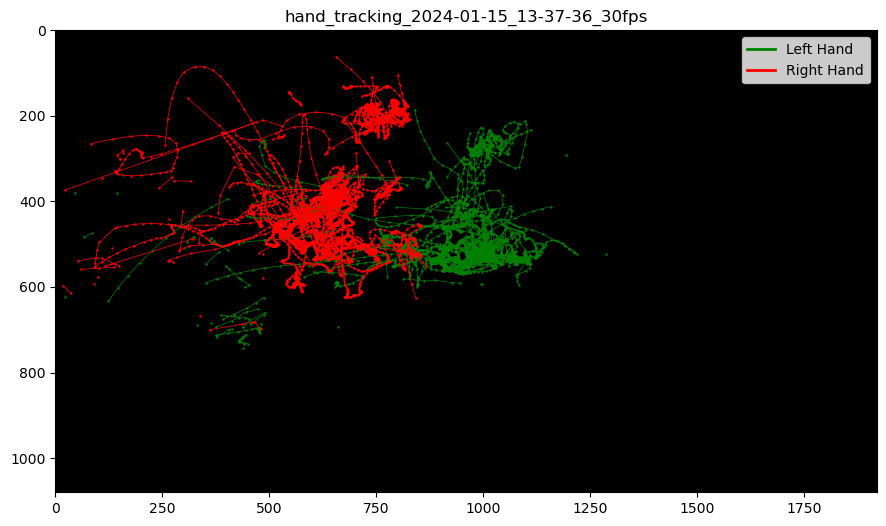

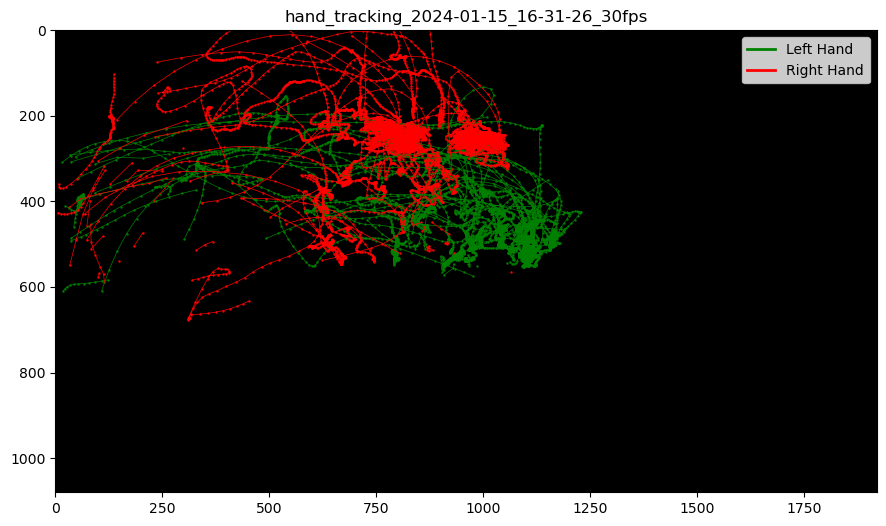

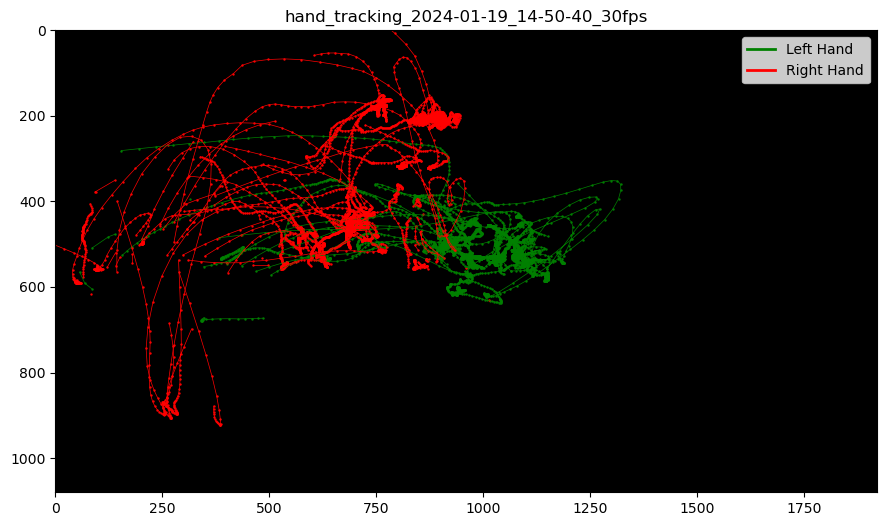

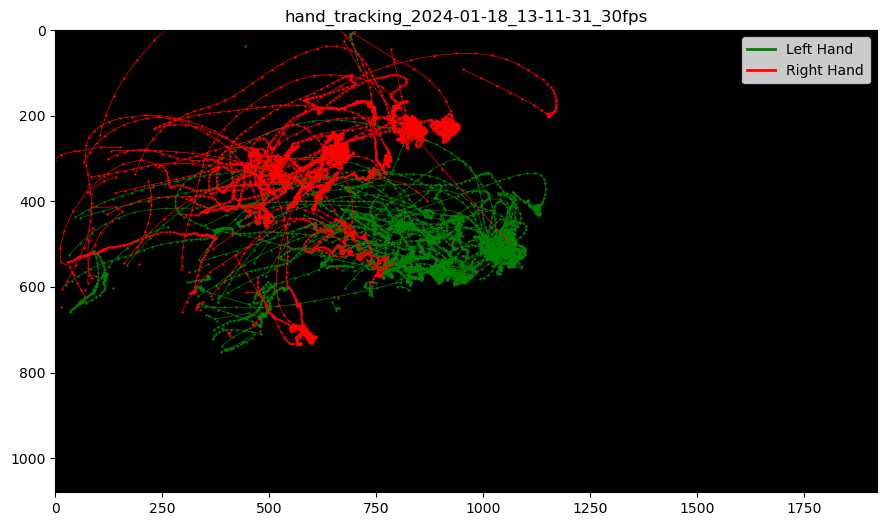

In [44]:
dfs = [df for df in os.listdir("output_dataframes") if df.endswith("30fps.pkl")]

for df_name in dfs:
    df = pd.read_pickle(os.path.join("output_dataframes", df_name))
    df_processed = postprocess_and_compute_distance(df, window=9, max_jump=85, min_disp=1.0)
    df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
    df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
    draw_hands(df_hand_left, df_hand_right, title=df_name.split(".")[0])

In [28]:
dfs10fps

['hand_tracking_2024-01-15_13-37-36_10fps.pkl',
 'hand_tracking_2024-01-15_16-31-26_10fps.pkl',
 'hand_tracking_2024-01-19_14-50-40_10fps.pkl',
 'hand_tracking_2024-01-18_13-11-31_10fps.pkl']

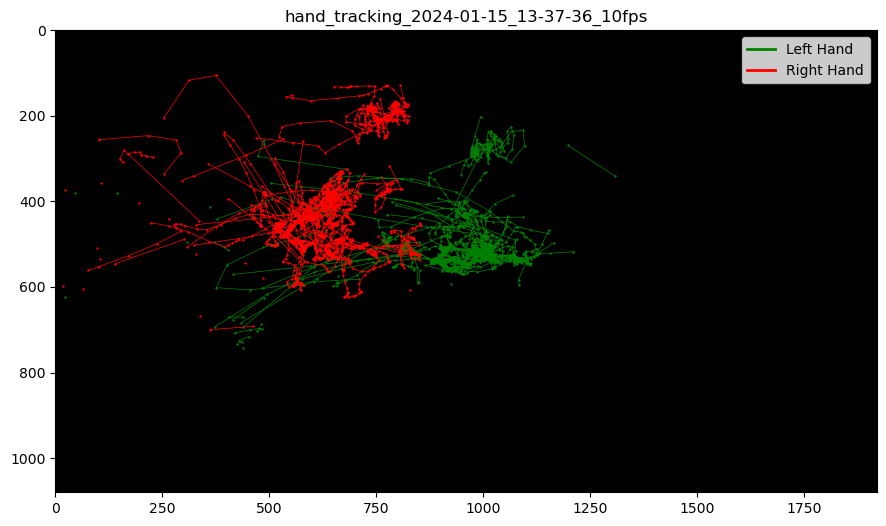

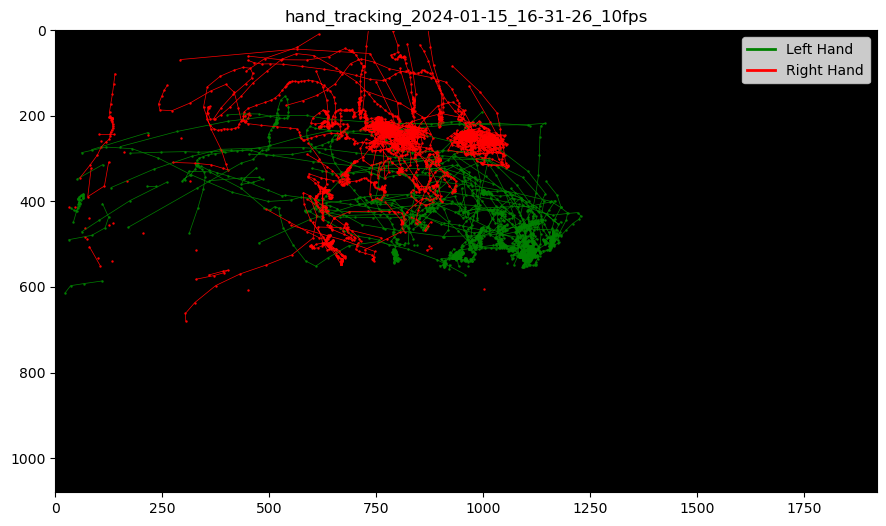

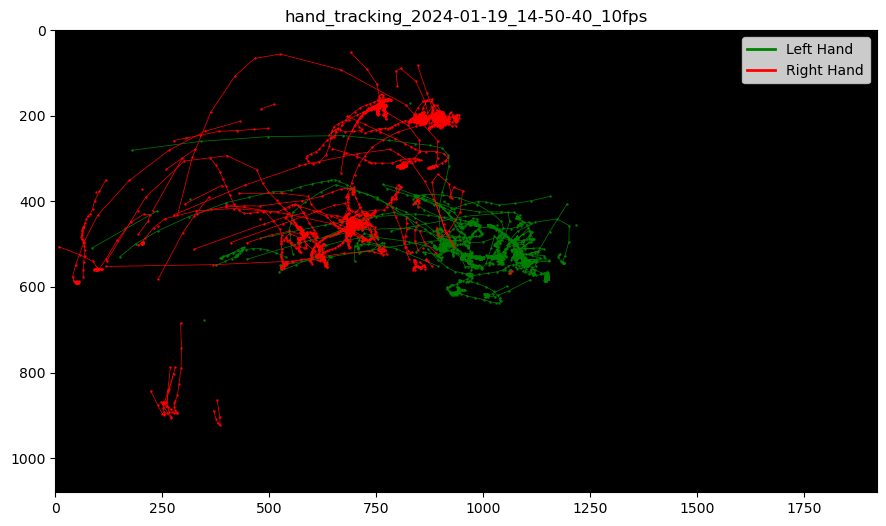

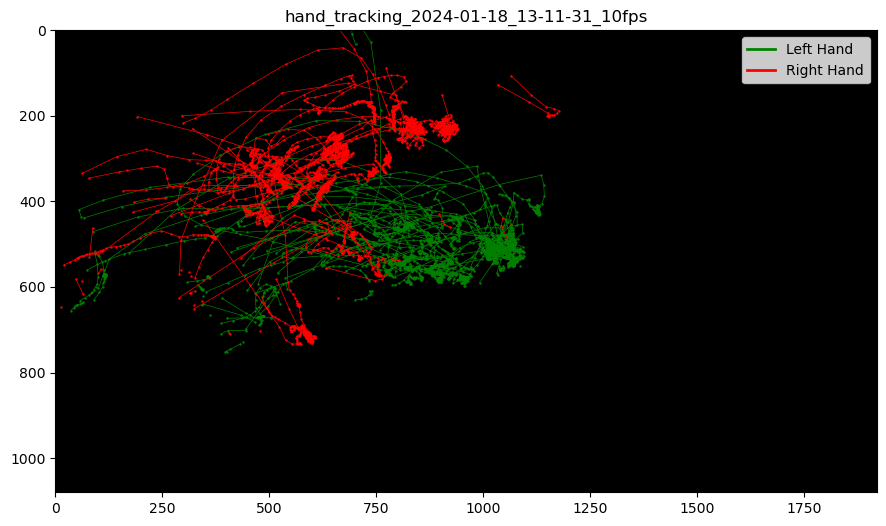

In [43]:
dfs10fps = [df.replace("30fps", "10fps") for df in dfs]

for df_name in dfs10fps:
    df = pd.read_pickle(os.path.join("output_dataframes", df_name))
    df_processed = postprocess_and_compute_distance(df)
    df_hand_left = df_processed[df_processed['hand_label'] == 'Left']
    df_hand_right = df_processed[df_processed['hand_label'] == 'Right']
    draw_hands(df_hand_left, df_hand_right, title=df_name.split(".")[0])

In [76]:
# Process all 10 fps tracked dataframes (just changed center_col=bbox_center)

out_dir = "output_dataframes"
processed_dir = "processed_dataframes"

tracked_dataframes = [f for f in os.listdir(out_dir) if f.endswith('_10fps.pkl')]
processed_dataframes = [f for f in os.listdir(processed_dir) if f.endswith('processed')]

for df_name in tqdm(tracked_dataframes):
    if df_name.replace('_10fps.pkl', '_processed.pkl') in processed_dataframes:
        continue  # already processed

    df = pd.read_pickle(os.path.join(out_dir, df_name))
    processed_df = postprocess_and_compute_distance(df, center_col='bbox_center')
    processed_df.to_pickle(os.path.join(processed_dir, df_name.replace('_10fps.pkl', '_10fps_processed.pkl')))
    print(f"Processed and saved: {df_name}")

  1%|          | 1/86 [00:07<10:59,  7.76s/it]

Processed and saved: hand_tracking_2024-01-22_17-16-51_10fps.pkl


  2%|▏         | 2/86 [00:18<13:26,  9.60s/it]

Processed and saved: hand_tracking_2024-01-17_16-22-28_10fps.pkl


  3%|▎         | 3/86 [00:22<09:31,  6.89s/it]

...

Processed and saved: hand_tracking_2024-01-18_14-39-24_10fps.pkl


 99%|█████████▉| 85/86 [10:43<00:09,  9.87s/it]

Processed and saved: hand_tracking_2024-01-23_10-35-15_10fps.pkl


100%|██████████| 86/86 [10:53<00:00,  7.60s/it]

Processed and saved: hand_tracking_2024-01-23_14-50-30_10fps.pkl


In [ ]:
# Process all 30 fps tracked dataframes

out_dir = "output_dataframes"
processed_dir = "processed_dataframes"

tracked_dataframes = [f for f in os.listdir(out_dir) if f.endswith('_30fps.pkl')]
processed_dataframes = [f for f in os.listdir(processed_dir) if f.endswith('processed')]

for df_name in tqdm(tracked_dataframes):
    if df_name.replace('_30fps.pkl', '_30fps_processed.pkl') in processed_dataframes:
        continue  # already processed

    df = pd.read_pickle(os.path.join(out_dir, df_name))
    processed_df = postprocess_and_compute_distance(df, window=9, max_jump=100, min_disp=1.0)
    processed_df.to_pickle(os.path.join(processed_dir, df_name.replace('_30fps.pkl', '_30fps_processed.pkl')))
    #print(f"Processed and saved: {df_name}")

  0%|          | 0/88 [00:00<?, ?it/s]

100%|██████████| 88/88 [32:17<00:00, 22.01s/it]   


# Metric related stuff
.  
.  
.  
.  
.  
.  
.  
.  
.  
.  



In [82]:
def compute_motion_metrics(df_hand, hand_label="Left", fps=30):
    df = df_hand.copy()

    # real time delta in seconds
    df["dt"] = df["frame_diff"] / fps

    # Avoid division by zero or invalid dt
    df = df[df["dt"] > 0]

    # velocity (px/s)
    df["velocity"] = df["disp_filtered"] / df["dt"]

    # acceleration (px/s^2)
    df["accel"] = df["velocity"].diff() / df["dt"]

    # jerk (px/s^3)
    df["jerk"] = df["accel"].diff() / df["dt"]

    # RMS values for smoothness
    rms_speed = np.sqrt((df["velocity"]**2).mean())
    rms_accel = np.sqrt((df["accel"]**2).mean())
    rms_jerk = np.sqrt((df["jerk"]**2).mean())

    # tremor approximation (since I sample at 10Hz likely not capturing high freq tremor)
    df["vel_smooth"] = df["velocity"].rolling(7, center=True, min_periods=1).mean()
    tremor_energy = ((df["velocity"] - df["vel_smooth"])**2).mean()

    # duty cycle (was the hand active vs idle?)
    velocity_threshold = 20.0  # px/s
    movement_time = (df['velocity'] > velocity_threshold).multiply(df['dt']).sum()
    total_time = df['dt'].sum()
    duty_cycle = movement_time / total_time


    df_metrics = pd.DataFrame({
        f"total_path_{hand_label.lower()}": [df["disp_filtered"].sum()],
        f"rms_speed_{hand_label.lower()}": [rms_speed],
        f"rms_accel_{hand_label.lower()}": [rms_accel],
        f"rms_jerk_{hand_label.lower()}": [rms_jerk],
        f"tremor_energy_{hand_label.lower()}": [tremor_energy],
        f"duty_cycle_{hand_label.lower()}": [duty_cycle],
    })
    
    return df_metrics

import numpy as np
import pandas as pd


def compute_dt_and_velocity(df, fps=30):

    # real time delta in seconds
    df["dt"] = df["frame_diff"] / fps

    # Avoid division by zero or invalid dt
    df = df[df["dt"] > 0]

    # velocity (px/s)
    df["velocity"] = df["disp_filtered"] / df["dt"]


import numpy as np
import pandas as pd

def compute_hand_skill_metrics(df_hand, hand_label="Left", fps=10, velocity_threshold=10.0):
    """
    Compute surgical skill metrics for a single hand trajectory.
    
    Parameters
    ----------
    df_hand : pd.DataFrame
        Must include: 'frame', 'disp_filtered', 'cx_smooth', 'cy_smooth'
    hand_label : str
        Name of the hand ("Left" or "Right") for naming columns
    fps : int
        Original video FPS
    velocity_threshold : float
        Threshold (px/sec) for defining active movement
    
    Returns
    -------
    pd.DataFrame
        Single-row DataFrame with skill metrics for this hand
    """
    df = df_hand.copy().sort_values("frame")

    # --- Compute dt in seconds (frame differences) ---
    df['frame_diff'] = df['frame'].diff().fillna(1)
    df['dt'] = df['frame_diff'] / fps

    # --- Compute velocity (px/sec) ---
    df['velocity'] = df['disp_filtered'] / df['dt'].replace(0, np.nan)

    # --- Economy of Motion: total path & curvature ---
    total_path = df['disp_filtered'].sum()

    # Rough curvature: angle change between consecutive segments
    dx = np.diff(df['cx_smooth'].fillna(method='ffill'))
    dy = np.diff(df['cy_smooth'].fillna(method='ffill'))
    path_vec = np.vstack([dx, dy]).T
    if len(path_vec) > 1:
        angles = np.arctan2(path_vec[1:,1], path_vec[1:,0]) - np.arctan2(path_vec[:-1,1], path_vec[:-1,0])
        angles = np.mod(angles + np.pi, 2*np.pi) - np.pi  # wrap [-pi, pi]
        mean_abs_angle_change = np.mean(np.abs(angles))
    else:
        mean_abs_angle_change = 0

    # --- Efficiency: path / duration & duty cycle ---
    duration = df['dt'].sum()
    efficiency = total_path / duration if duration > 0 else np.nan

    movement_time = (df['velocity'] > velocity_threshold).multiply(df['dt']).sum()
    duty_cycle = movement_time / duration if duration > 0 else np.nan

    # --- Tremor proxy: RMS velocity during "stationary" periods ---
    stationary_mask = df['velocity'] < velocity_threshold
    tremor_rms = np.sqrt((df.loc[stationary_mask, 'velocity']**2).mean()) if stationary_mask.any() else 0

    # --- Build single-row DataFrame ---
    metrics = pd.DataFrame([{
        f"total_path_{hand_label.lower()}": total_path,
        f"mean_abs_angle_change_{hand_label.lower()}": mean_abs_angle_change,
        f"efficiency_{hand_label.lower()}": efficiency,
        f"duty_cycle_{hand_label.lower()}": duty_cycle,
        f"tremor_rms_{hand_label.lower()}": tremor_rms
    }])

    return metrics

import numpy as np
import pandas as pd

def compute_extended_hand_metrics(df_hand, hand_label="Left", fps=10, velocity_threshold=10.0):
    """
    Compute extended surgical skill metrics for a single hand trajectory.
    
    Parameters
    ----------
    df_hand : pd.DataFrame
        Must include: 'frame', 'disp_filtered', 'cx_smooth', 'cy_smooth'
    hand_label : str
        Name of the hand ("Left" or "Right")
    fps : int
        Original video FPS
    velocity_threshold : float
        Threshold (px/sec) for defining active movement
    
    Returns
    -------
    pd.DataFrame
        Single-row DataFrame with extended skill metrics
    """
    df = df_hand.copy().sort_values("frame")

    # --- Compute dt ---
    df['frame_diff'] = df['frame'].diff().fillna(1)
    df['dt'] = df['frame_diff'] / fps

    # --- Velocity & acceleration ---
    df['velocity'] = df['disp_filtered'] / df['dt'].replace(0, np.nan)
    df['accel'] = df['velocity'].diff() / df['dt'].replace(0, np.nan)

    # --- Economy of Motion (path, curvature) ---
    total_path = df['disp_filtered'].sum()

    dx = np.diff(df['cx_smooth'].fillna(method='ffill'))
    dy = np.diff(df['cy_smooth'].fillna(method='ffill'))
    path_vec = np.vstack([dx, dy]).T

    if len(path_vec) > 1:
        angles = np.arctan2(path_vec[1:,1], path_vec[1:,0]) - np.arctan2(path_vec[:-1,1], path_vec[:-1,0])
        angles = np.mod(angles + np.pi, 2*np.pi) - np.pi
        mean_abs_angle_change = np.mean(np.abs(angles))
        num_reversals = np.sum(np.diff(np.sign(angles)) != 0)  # rough reversal count
    else:
        mean_abs_angle_change = 0
        num_reversals = 0

    # --- Efficiency ---
    duration = df['dt'].sum()
    mean_velocity = df['velocity'].mean()
    rms_accel = np.sqrt((df['accel']**2).mean())
    efficiency = total_path / duration if duration > 0 else np.nan

    # --- Duty cycle: time fraction moving ---
    movement_time = (df['velocity'] > velocity_threshold).multiply(df['dt']).sum()
    duty_cycle = movement_time / duration if duration > 0 else np.nan

    # --- Tremor / micro-movements ---
    stationary_mask = df['velocity'] < velocity_threshold
    tremor_rms = np.sqrt((df.loc[stationary_mask, 'velocity']**2).mean()) if stationary_mask.any() else 0

    # --- Movement intermittency ratio ---
    moving = df['velocity'] > velocity_threshold
    if moving.any():
        intermittency_ratio = moving.astype(int).diff().abs().sum() / len(moving)
    else:
        intermittency_ratio = 0

    # --- Build single-row DataFrame ---
    metrics = pd.DataFrame([{
        f"total_path_{hand_label.lower()}": total_path,
        f"mean_velocity_{hand_label.lower()}": mean_velocity,
        f"rms_accel_{hand_label.lower()}": rms_accel,
        f"efficiency_{hand_label.lower()}": efficiency,
        f"duty_cycle_{hand_label.lower()}": duty_cycle,
        f"tremor_rms_{hand_label.lower()}": tremor_rms,
        f"mean_abs_angle_change_{hand_label.lower()}": mean_abs_angle_change,
        f"num_reversals_{hand_label.lower()}": num_reversals,
        f"intermittency_ratio_{hand_label.lower()}": intermittency_ratio
    }])

    return metrics



In [80]:
import os
import pandas as pd
from scipy import stats

def analyze_metrics_vs_grs(
    processed_dir: str,
    ratings_csv: str,
    metric_func,
    fps: int = 30,
):
    """
    Compute motion metrics for each hand in each processed file and correlate
    with GRS ratings.

    metric_func(df_hand, hand_label, fps) must return a DataFrame with one row.
    """
    
    processed_files = sorted([
        f for f in os.listdir(processed_dir)
        if f.endswith("processed.pkl")
    ])

    df_ratings = pd.read_csv(ratings_csv)
    df_metrics = pd.DataFrame()

    for df_name in tqdm(processed_files):
        df = pd.read_pickle(os.path.join(processed_dir, df_name))

        df_left = df[df['hand_label'] == 'Left']
        df_right = df[df['hand_label'] == 'Right']

        # your compute func returns a row-shaped DataFrame
        metrics_left = metric_func(df_left, hand_label="Left", fps=fps)
        metrics_right = metric_func(df_right, hand_label="Right", fps=fps)

        # merge side-by-side into one row
        metrics = pd.concat([metrics_left, metrics_right], axis=1)
        df_metrics["file"] = df_name

        df_metrics = pd.concat([df_metrics, metrics], ignore_index=True)

    # --- Merge Motion Metrics with Ratings ---
    df_full = pd.concat([df_ratings.reset_index(drop=True), df_metrics.reset_index(drop=True)], axis=1)

    # --- Compute Correlations vs GRS ---
    correlations = {}
    for col in df_metrics.columns:
        if col == "file": 
            continue
        if df_full[col].isna().all():
            continue
        r, p = stats.pearsonr(df_full["GRS_Total"], df_full[col])
        correlations[col] = {"correlation": r, "p_value": p}

    return df_metrics, correlations


In [ ]:
out_dir = "output_dataframes"
processed_dir = "processed_dataframes"

tracked_dataframes = [f for f in os.listdir(out_dir) if f.endswith('_10fps.pkl')]
processed_dataframes = [f for f in os.listdir(processed_dir) if f.endswith('processed')]
processed_dataframes.sort()

df_metrics = pd.DataFrame(columns=["file", "tot_path_length_right", "tot_path_length_left", "ratio_right", "ratio_left", "total_path_length"])
for df_name in processed_dataframes:
    
    df = pd.read_pickle(os.path.join(processed_dir, df_name))

    df_hand_left = df[df['hand_label'] == 'Left']
    df_hand_right = df[df['hand_label'] == 'Right']

    rr = df_hand_right.frame.max() / 3 / len(df_hand_right)
    lr = df_hand_left.frame.max() / 3 / len(df_hand_left)

    # need to rethink if scaling like this makes sense
    # maybe a better alternative is to not scale but use a larger acceptable max_gap_sec from 0.2 to 0.4 for example
    # or to check if tracking loss is withing frame or due to hand leaving the frame and scale with respect to that
    tot_path_length_right = df_hand_right['disp_filtered'].sum()
    tot_path_length_left = df_hand_left['disp_filtered'].sum()
    total_path_length = tot_path_length_right + tot_path_length_left

    # velocity computations
    df_hand_right["velocity"] = df_hand_right["disp_filtered"] * 30 / df_hand_right["frame_diff"]
    df_hand_left["velocity"] = df_hand_left["disp_filtered"] * 30 / df_hand_left["frame_diff"]

    # mean translational velocity
    v_mean_left = df_hand_left["velocity"].mean(skipna=True)
    v_mean_right = df_hand_right["velocity"].mean(skipna=True)

    # standard deviation of velocity
    v_std_left = df_hand_left["velocity"].std(skipna=True)
    v_std_right = df_hand_right["velocity"].std(skipna=True)

    # Movement smoothnes (jerk)
    df_hand_right["acceleration"] = df_hand_right["velocity"].diff() * 30 / df_hand_right["frame_diff"]
    df_hand_left["acceleration"] = df_hand_left["velocity"].diff() * 30 / df_hand_left["frame_diff"]

    # mean acceleration
    a_mean_left = df_hand_left["acceleration"].mean(skipna=True)
    a_mean_right = df_hand_right["acceleration"].mean(skipna=True)

    # standard deviation of acceleration
    a_std_left = df_hand_left["acceleration"].std(skipna=True)
    a_std_right = df_hand_right["acceleration"].std(skipna=True)

    # total time (in seconds)
    total_time = max(df_hand_right['frame'].max() / 30, df_hand_left['frame'].max() / 30)


    df_metrics = pd.concat([df_metrics, pd.DataFrame({
        "file": [df_name],
        "tot_path_length_right": [tot_path_length_right],
        "tot_path_length_left": [tot_path_length_left],
        "ratio_right": [rr],
        "ratio_left": [lr],
        "total_path_length": [total_path_length],
        "v_mean_left": [v_mean_left],
        "v_mean_right": [v_mean_right],
        "v_std_left": [v_std_left],
        "v_std_right": [v_std_right],
        "a_mean_left": [a_mean_left],
        "a_mean_right": [a_mean_right],
        "a_std_left": [a_std_left],
        "a_std_right": [a_std_right],
        "total_time": [total_time]
    })], ignore_index=True)

    print(f"File: {df_name} | Right Hand tot path length: {tot_path_length_right:.2f} (ratio: {rr:.3f}) | Left Hand tot path length: {tot_path_length_left:.2f} (ratio: {lr:.3f})")

df_metrics

/var/folders/sj/219f9qbn3y15yynshcyrrp3c0000gn/T/ipykernel_9720/190836830.py:37: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_metrics = pd.concat([df_metrics, pd.DataFrame({


File: hand_tracking_2024-01-15_13-18-23_10fps.pkl | Right Hand tot path length: 42594.13 (ratio: 1.357) | Left Hand tot path length: 39325.70 (ratio: 1.264)
File: hand_tracking_2024-01-15_13-37-36_10fps.pkl | Right Hand tot path length: 22661.94 (ratio: 1.326) | Left Hand tot path length: 25983.28 (ratio: 1.349)
File: hand_tracking_2024-01-15_14-03-23_10fps.pkl | Right Hand tot path length: 40434.64 (ratio: 1.166) | Left Hand tot path length: 36960.86 (ratio: 1.341)
File: hand_tracking_2024-01-15_14-32-45_10fps.pkl | Right Hand tot path length: 78496.13 (ratio: 1.275) | Left Hand tot path length: 62439.54 (ratio: 1.118)
File: hand_tracking_2024-01-15_15-05-31_10fps.pkl | Right Hand tot path length: 62970.02 (ratio: 1.157) | Left Hand tot path length: 54545.37 (ratio: 1.149)
File: hand_tracking_2024-01-15_15-38-13_10fps.pkl | Right Hand tot path length: 51430.03 (ratio: 1.217) | Left Hand tot path length: 43993.45 (ratio: 1.256)
File: hand_tracking_2024-01-15_15-58-44_10fps.pkl | Right 

,file,tot_path_length_right,tot_path_length_left,ratio_right,ratio_left,total_path_length,v_mean_left,v_mean_right,v_std_left,v_std_right,total_time
0,hand_tracking_2024-01-15_13-18-23_10fps.pkl,42594.131164,39325.699201,1.357376,1.263687,81919.830366,86.530635,100.941580,195.097516,171.369256,540.1
1,hand_tracking_2024-01-15_13-37-36_10fps.pkl,22661.942138,25983.281687,1.325656,1.348641,48645.223825,103.286759,97.485435,266.646814,170.268139,287.8
2,hand_tracking_2024-01-15_14-03-23_10fps.pkl,40434.644477,36960.858001,1.166253,1.340513,77395.502478,110.119046,107.876550,196.417892,162.522425,423.2
3,hand_tracking_2024-01-15_14-32-45_10fps.pkl,78496.132023,62439.537603,1.274679,1.118242,140935.669626,51.745795,76.023448,152.875255,112.133029,1282.4
4,hand_tracking_2024-01-15_15-05-31_10fps.pkl,62970.022380,54545.370507,1.157316,1.149125,117515.392887,58.618912,70.222350,155.644349,115.859087,1011.0
...,...,...,...,...,...,...,...,...,...,...,...
82,hand_tracking_2024-01-24_16-21-06_10fps.pkl,30551.819931,27307.818770,1.301900,1.440047,57859.638701,101.525005,105.559334,217.402705,150.304376,363.9
83,hand_tracking_2024-01-24_16-52-58_10fps.pkl,61635.264796,68017.810135,1.269118,1.208958,129653.074931,106.750538,105.941307,209.044217,166.041897,693.7
84,hand_tracking_2024-01-24_17-19-03_10fps.pkl,48010.078704,41298.477980,1.206417,1.817480,89308.556684,112.041555,91.421770,216.822269,146.729987,590.3
85,hand_tracking_2024-01-24_17-41-55_10fps.pkl,52704.800359,29418.969764,1.200679,1.882949,82123.770123,107.553561,121.034064,211.436007,172.996141,494.8


In [9]:
# Merge metrics dataframe with ratings dataframe
df_ratings_and_metrics = pd.concat([df_ratings, df_metrics], axis=1)
df_ratings_and_metrics

,Participant Number,Age,Gender,Case_Number,Experience_Total,Position,GRS_Total,OSATS_Total,CFS_Total,Self_Rating,...,tot_path_length_right,tot_path_length_left,ratio_right,ratio_left,total_path_length,v_mean_left,v_mean_right,v_std_left,v_std_right,total_time
0,1,28,m,1,2.0,Assistenzarzt/Assistenzärztin,59.25,23.00,9.25,3.0,...,42594.131164,39325.699201,1.357376,1.263687,81919.830366,86.530635,100.941580,195.097516,171.369256,540.1
1,1,28,m,2,2.0,Assistenzarzt/Assistenzärztin,54.40,24.60,10.80,4.0,...,22661.942138,25983.281687,1.325656,1.348641,48645.223825,103.286759,97.485435,266.646814,170.268139,287.8
2,1,28,m,3,2.0,Assistenzarzt/Assistenzärztin,74.50,30.00,9.50,4.0,...,40434.644477,36960.858001,1.166253,1.340513,77395.502478,110.119046,107.876550,196.417892,162.522425,423.2
3,2,28,m,1,3.0,Assistenzarzt/Assistenzärztin,49.25,19.50,9.50,1.0,...,78496.132023,62439.537603,1.274679,1.118242,140935.669626,51.745795,76.023448,152.875255,112.133029,1282.4
4,2,28,m,2,3.0,Assistenzarzt/Assistenzärztin,49.00,16.50,8.00,1.0,...,62970.022380,54545.370507,1.157316,1.149125,117515.392887,58.618912,70.222350,155.644349,115.859087,1011.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,28,31,m,2,4.0,Assistenzarzt/Assistenzärztin,72.25,35.25,12.25,5.0,...,19820.518370,25543.582230,1.395683,1.255982,45364.100600,91.397096,79.007771,210.754416,143.880417,330.7
82,28,31,m,3,4.0,Assistenzarzt/Assistenzärztin,70.00,28.25,9.75,5.0,...,30551.819931,27307.818770,1.301900,1.440047,57859.638701,101.525005,105.559334,217.402705,150.304376,363.9
83,29,24,w,1,0.0,Unterassistenzarzt/Unterassistenzärztin,49.75,18.00,10.50,4.0,...,61635.264796,68017.810135,1.269118,1.208958,129653.074931,106.750538,105.941307,209.044217,166.041897,693.7
84,29,24,w,2,0.0,Unterassistenzarzt/Unterassistenzärztin,62.00,32.75,10.50,2.0,...,48010.078704,41298.477980,1.206417,1.817480,89308.556684,112.041555,91.421770,216.822269,146.729987,590.3


In [12]:
# Pearson correlation between GRS ratings and total_path_length, v_mean_left, v_mean_right, v_std_left, v_std_right, total_time
import scipy.stats as stats

correlations = {}
for col in ["tot_path_length_right", "tot_path_length_left", "v_mean_left", "v_mean_right", "v_std_left", "v_std_right", "total_time"]:
    corr, _ = stats.pearsonr(df_ratings_and_metrics["GRS_Total"], df_ratings_and_metrics[col])
    p_value = stats.pearsonr(df_ratings_and_metrics["GRS_Total"], df_ratings_and_metrics[col])[1]
    correlations[col] = {"correlation": corr, "p_value": p_value}

correlations

{'tot_path_length_right': {'correlation': -0.6844315901218031,
  'p_value': 3.7204096943396846e-13},
 'tot_path_length_left': {'correlation': -0.5676184132673847,
  'p_value': 1.2047970649915857e-08},
 'v_mean_left': {'correlation': 0.2729367885364932,
  'p_value': 0.011004848048121789},
 'v_mean_right': {'correlation': 0.002816490824799906,
  'p_value': 0.979467187008293},
 'v_std_left': {'correlation': 0.32751590698224325,
  'p_value': 0.002082646474354786},
 'v_std_right': {'correlation': 0.09090728051812963,
  'p_value': 0.405166983628008},
 'total_time': {'correlation': -0.6446399486433577,
  'p_value': 2.115474620565577e-11}}

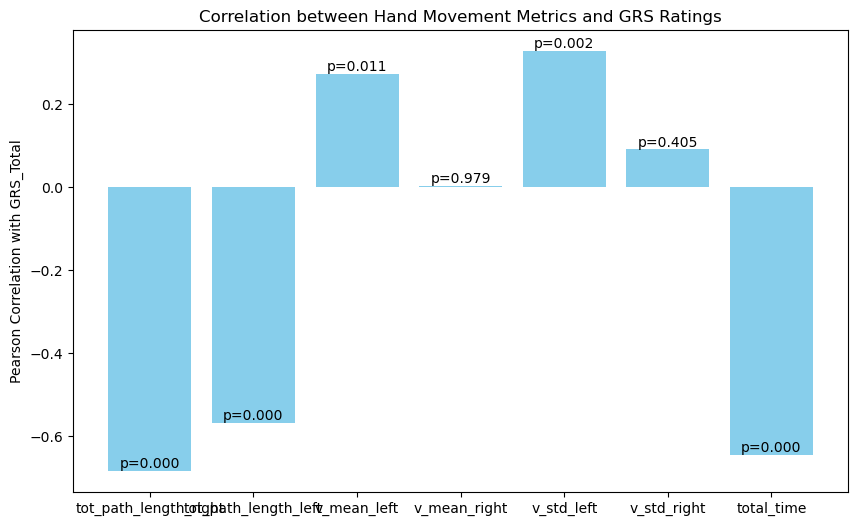

In [13]:
# make a bar plot of the correlations with the p_values diplayed on top
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
plt.bar(correlations.keys(), [v["correlation"] for v in correlations.values()],
        color='skyblue')
plt.ylabel("Pearson Correlation with GRS_Total")
plt.title("Correlation between Hand Movement Metrics and GRS Ratings")
for i, (col, vals) in enumerate(correlations.items()):
    plt.text(i, vals["correlation"], f'p={vals["p_value"]:.3f}', ha='center', va='bottom')

segment_id                990.000000
total_disp             133045.154490
total_disp_filtered    131412.809868
total_disp_raw         184123.342947
dtype: float64
segment_id              2701.000000
total_disp             47498.182070
total_disp_filtered    46002.428047
total_disp_raw         58685.198070
dtype: float64


.

.

.

.

.
.
.
.
.
.
.